In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))
from src.analysis.metrics import calculate_rmse, calculate_mape

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error

In [2]:
# Generate datetime index
date_range = pd.date_range(start='2023-01-01', periods=500, freq='D')

In [3]:
# Generate sinusoidal data
t = np.linspace(0, 100, 500)
y1 = np.sin(t)
y2 = np.sin(t + np.pi/4)
data = pd.DataFrame({'y1': y1, 'y2': y2}, index=date_range)

In [4]:
data

,y1,y2
2023-01-01,0.000000,0.707107
2023-01-02,0.199062,0.833714
2023-01-03,0.390157,0.926950
2023-01-04,0.565634,0.983084
2023-01-05,0.718472,0.999869
...,...,...
2024-05-10,-0.971758,-0.520272
2024-05-11,-0.905335,-0.339861
2024-05-12,-0.802675,-0.145846
2024-05-13,-0.667887,0.054006


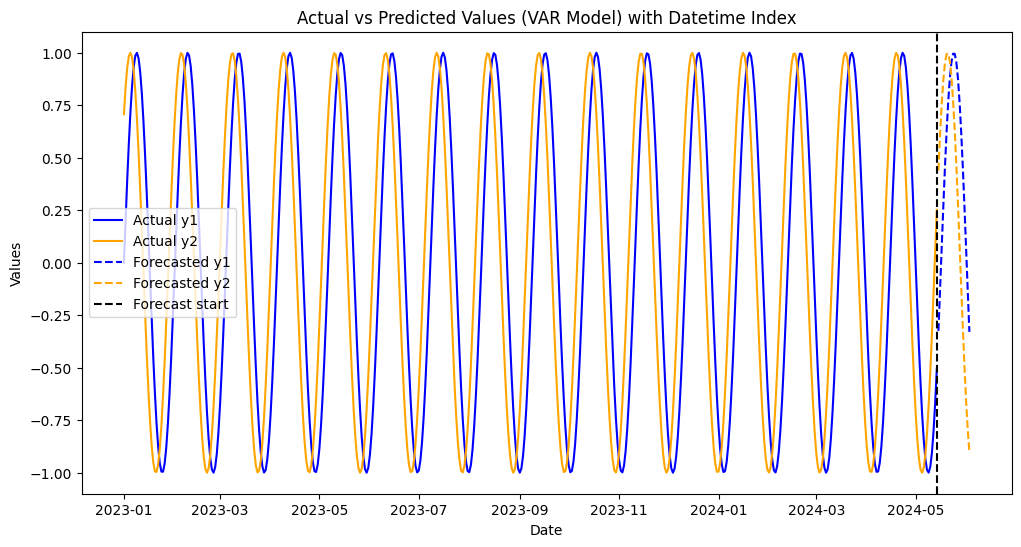

In [5]:
# Fit the VAR model
model = VAR(data)
fitted_model = model.fit(maxlags=15, ic='aic')

# Forecasting the next 20 steps
n_forecast = 20
forecast_input = data.values[-fitted_model.k_ar:]  # Use the last k_ar observations to start the forecast
forecast = fitted_model.forecast(y=forecast_input, steps=n_forecast)

# Prepare data for plotting
# Create a new datetime index for the forecasted values
forecast_index = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=n_forecast, freq='D')
forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=data.columns)

# Plot the actual data and the forecasts
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['y1'], label='Actual y1', color='blue')
plt.plot(data.index, data['y2'], label='Actual y2', color='orange')
plt.plot(forecast_df.index, forecast_df['y1'], label='Forecasted y1', color='blue', linestyle='dashed')
plt.plot(forecast_df.index, forecast_df['y2'], label='Forecasted y2', color='orange', linestyle='dashed')
plt.axvline(x=data.index[-1], color='black', linestyle='--', label='Forecast start')
plt.legend()
plt.title("Actual vs Predicted Values (VAR Model) with Datetime Index")
plt.xlabel("Date")
plt.ylabel("Values")
plt.show()